In [ ]:
!pip install numpy pandas scipy matplotlib seaborn scikit-learn xgboost neurokit2 tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.1 MB/s eta 0:00:00


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import linregress

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_curve, auc
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, LeaveOneGroupOut


from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score, ConfusionMatrixDisplay, classification_report
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# @title
import shutil
import os

# Path to your uploaded WESAD.zip in Drive
zip_path = '/content/drive/MyDrive/WESAD_dataset/WESAD.zip'

# Destination in Colab
dest_path = '/content/WESAD.zip'

# Copy to Colab
shutil.copy(zip_path, dest_path)

# Create folder to extract
os.makedirs('/content/', exist_ok=True)

# Unzip
!unzip -q /content/WESAD.zip -d /content/

In [ ]:
WESAD_PATH = "/content/WESAD"

In [ ]:
FS          = 700
WINDOW_SEC  = 60
STEP_SEC    = 30
WINDOW_SIZE = FS * WINDOW_SEC
STEP_SIZE   = FS * STEP_SEC
LABEL_MAP   = {1: 0, 2: 1}   # 1=Baseline→0, 2=Stress→1
SUBJECTS    = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
CLASS_NAMES = ["Baseline", "Anxiety"]

FEATURE_NAMES = [
    "ecg_mean", "ecg_std", "ecg_min", "ecg_max", "ecg_rms",
    "ecg_hrv_std", "ecg_hrv_mean",
    "eda_mean", "eda_std", "eda_min", "eda_max", "eda_slope", "eda_npeaks"
]


In [ ]:
def extract_eda_features(segment):
    mean  = np.mean(segment)
    std   = np.std(segment)
    mn    = np.min(segment)
    mx    = np.max(segment)
    slope, *_ = linregress(np.arange(len(segment)), segment)
    peaks, _  = find_peaks(segment, distance=FS // 2)
    return [mean, std, mn, mx, slope, len(peaks)]

def extract_ecg_features(segment):
    mean = np.mean(segment)
    std  = np.std(segment)
    mn   = np.min(segment)
    mx   = np.max(segment)
    rms  = np.sqrt(np.mean(segment ** 2))
    peaks, _ = find_peaks(segment, distance=int(FS * 0.4), height=np.mean(segment))
    if len(peaks) > 1:
        rr       = np.diff(peaks) / FS * 1000
        hrv_std  = np.std(rr)
        hrv_mean = np.mean(rr)
    else:
        hrv_std, hrv_mean = 0.0, 0.0
    return [mean, std, mn, mx, rms, hrv_std, hrv_mean]

In [ ]:
def load_subject(sid):
    path = os.path.join(WESAD_PATH, f"S{sid}", f"S{sid}.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    ecg    = data["signal"]["chest"]["ECG"].flatten().astype(np.float32)
    eda    = data["signal"]["chest"]["EDA"].flatten().astype(np.float32)
    labels = data["label"].flatten().astype(int)
    return ecg, eda, labels

def extract_windows(ecg, eda, labels):
    X_list, y_list = [], []
    n = min(len(ecg), len(eda), len(labels))
    for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        end        = start + WINDOW_SIZE
        win_labels = labels[start:end]
        unique, counts = np.unique(win_labels, return_counts=True)
        maj = unique[np.argmax(counts)]
        if maj not in LABEL_MAP:
            continue
        X_list.append(extract_ecg_features(ecg[start:end]) +
                      extract_eda_features(eda[start:end]))
        y_list.append(LABEL_MAP[maj])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=int)

print("Loading WESAD subjects and extracting features...\n")
all_X, all_y, all_groups = [], [], []

for sid in SUBJECTS:
    try:
        ecg, eda, labels = load_subject(sid)
        X, y = extract_windows(ecg, eda, labels)
        all_X.append(X)
        all_y.append(y)
        all_groups.extend([sid] * len(y))
        dist = dict(zip(*np.unique(y, return_counts=True)))
        print(f"  S{sid:2d}: {len(y):4d} windows | {dist}")
    except FileNotFoundError:
        print(f"  S{sid}: not found — skipping")

X_all  = np.vstack(all_X)
y_all  = np.hstack(all_y)
groups = np.array(all_groups)

print(f"\nTotal: {len(y_all)} windows | {X_all.shape[1]} features")
print(f"Class dist — Baseline: {np.sum(y_all==0)}, Anxiety: {np.sum(y_all==1)}\n")

Loading WESAD subjects and extracting features...

  S 2:   59 windows | {np.int64(0): np.int64(38), np.int64(1): np.int64(21)}
  S 3:   60 windows | {np.int64(0): np.int64(38), np.int64(1): np.int64(22)}
  S 4:   60 windows | {np.int64(0): np.int64(39), np.int64(1): np.int64(21)}
  S 5:   61 windows | {np.int64(0): np.int64(40), np.int64(1): np.int64(21)}
  S 6:   61 windows | {np.int64(0): np.int64(39), np.int64(1): np.int64(22)}
  S 7:   60 windows | {np.int64(0): np.int64(39), np.int64(1): np.int64(21)}
  S 8:   62 windows | {np.int64(0): np.int64(39), np.int64(1): np.int64(23)}
  S 9:   60 windows | {np.int64(0): np.int64(39), np.int64(1): np.int64(21)}
  S10:   63 windows | {np.int64(0): np.int64(39), np.int64(1): np.int64(24)}
  S11:   63 windows | {np.int64(0): np.int64(40), np.int64(1): np.int64(23)}
  S13:   62 windows | {np.int64(0): np.int64(40), np.int64(1): np.int64(22)}
  S14:   62 windows | {np.int64(0): np.int64(40), np.int64(1): np.int64(22)}
  S15:   62 windows | {np

In [ ]:
def get_models():
  return {
      "LDA": (
          LinearDiscriminantAnalysis(),
          {"classifier__solver": ["svd", "lsqr"],
           "classifier__tol": [1e-4, 1e-3]}
      ),
      "KNN": (
          KNeighborsClassifier(),
          {"classifier__n_neighbors": [3, 5, 7, 9],
           "classifier__metric": ["euclidean", "manhattan"]}
      ),
      "SVM": (
          SVC(probability=True, random_state=42),
          {"classifier__C": [0.1, 1, 10],
           "classifier__kernel": ["rbf", "linear"],
           "classifier__gamma": ["scale", "auto"]}
      ),
      "AdaBoost": (
            AdaBoostClassifier(random_state=42),
            {"classifier__n_estimators":  [50, 100, 150],
             "classifier__learning_rate": [0.5, 1.0]}
        ),
        "XGBoost": (
            XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                          eval_metric="logloss",
                          random_state=42, n_jobs=-1),
            {}
        ),
        "RandomForest": (
            RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                   random_state=42, n_jobs=-1),
            {}
        ),
        "LogisticRegression": (
            LogisticRegression(max_iter=1000, random_state=42),
            {"classifier__C":      [0.01, 0.1, 1, 10],
             "classifier__solver": ["lbfgs", "liblinear"]}
        ),

  }

In [ ]:
logo = LeaveOneGroupOut()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_store = {name: {"y_true": [], "y_pred": [], "y_proba": [], "subject": []}
              for name in get_models()}

n_folds = logo.get_n_splits(X_all, y_all, groups)
print(f"LOSO: {n_folds} folds ({n_folds} subjects)\n{'='*60}")

for fold_idx,  (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups)):

  test_subject = np.unique(groups[test_idx])[0]
  X_tr, X_te = X_all[train_idx], X_all[test_idx]
  y_tr, y_te = y_all[train_idx], y_all[test_idx]

  smote = SMOTE(random_state=42)
  try:
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
  except ValueError:
    X_tr_res, y_tr_res = X_tr, y_tr

  print(f"\nFold {fold_idx+1:2d} | Test subject: S{test_subject}"
        f"({len(y_te)} windows) | Train: {len(y_tr_res)} windows (after SMOTE)")

  for name, (clf, param_grid) in get_models().items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", clf)
    ])

    if param_grid:
            gs = GridSearchCV(pipe, param_grid, cv=skf,
                              scoring="f1", n_jobs=-1, refit=True)
            gs.fit(X_tr_res, y_tr_res)
            best_model = gs.best_estimator_
    else:
      pipe.fit(X_tr_res, y_tr_res)
      best_model = pipe

    y_pred  = best_model.predict(X_te)
    y_proba = (best_model.predict_proba(X_te)[:, 1]
    if hasattr(best_model, "predict_proba") else y_pred.astype(float))

    fold_store[name]["y_true"].extend(y_te.tolist())
    fold_store[name]["y_pred"].extend(y_pred.tolist())
    fold_store[name]["y_proba"].extend(y_proba.tolist())
    fold_store[name]["subject"].extend([test_subject] * len(y_te))

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    print(f"    {name:<20s}  acc={acc:.3f}  f1={f1:.3f}")

print(f"\n{'='*60}\nLOSO complete.\n")

LOSO: 15 folds (15 subjects)

Fold  1 | Test subject: S2(59 windows) | Train: 1098 windows (after SMOTE)
    LDA                   acc=0.169  f1=0.269
    KNN                   acc=0.390  f1=0.500
    SVM                   acc=0.271  f1=0.427
    AdaBoost              acc=0.305  f1=0.388
    XGBoost               acc=0.271  f1=0.377
    RandomForest          acc=0.424  f1=0.528
    LogisticRegression    acc=0.441  f1=0.267

Fold  2 | Test subject: S3(60 windows) | Train: 1098 windows (after SMOTE)
    LDA                   acc=0.850  f1=0.769
    KNN                   acc=0.850  f1=0.780
    SVM                   acc=0.783  f1=0.606
    AdaBoost              acc=0.883  f1=0.811
    XGBoost               acc=0.900  f1=0.842
    RandomForest          acc=0.917  f1=0.872
    LogisticRegression    acc=0.850  f1=0.780

Fold  3 | Test subject: S4(60 windows) | Train: 1096 windows (after SMOTE)
    LDA                   acc=0.967  f1=0.950
    KNN                   acc=0.883  f1=0.800
    SVM

In [ ]:
rows = []
all_cms = {}

for name, store in fold_store.items():
  yt = np.array(store["y_true"])
  yp = np.array(store["y_pred"])
  yb = np.array(store["y_proba"])

  row = {
      "Model": name,
      "Accuracy":  round(accuracy_score(yt, yp),                          4),
      "ROC-AUC":   round(roc_auc_score(yt, yb),                           4),
      "F1-Score":  round(f1_score(yt, yp, zero_division=0),               4),
      "Precision": round(precision_score(yt, yp, zero_division=0),        4),
      "Recall":    round(recall_score(yt, yp, zero_division=0),           4),
      "MCC":       round(matthews_corrcoef(yt, yp),                       4),
  }
  rows.append(row)
  all_cms[name] = confusion_matrix(yt, yp)

results_df = pd.DataFrame(rows).set_index("Model").sort_values("Accuracy", ascending=True)

print("="*80)
print("Performance Metrics of the Models Trained")
print("="*80)
print(results_df.to_string())

Performance Metrics of the Models Trained
                    Accuracy  ROC-AUC  F1-Score  Precision  Recall     MCC
Model                                                                     
SVM                   0.7247   0.8480    0.6622     0.5947  0.7470  0.4430
KNN                   0.7639   0.8433    0.7118     0.6366  0.8072  0.5270
LDA                   0.7900   0.8860    0.7286     0.6834  0.7801  0.5618
LogisticRegression    0.8226   0.8918    0.7668     0.7302  0.8072  0.6263
XGBoost               0.8422   0.9256    0.7896     0.7619  0.8193  0.6647
AdaBoost              0.8607   0.9070    0.8134     0.7881  0.8404  0.7034
RandomForest          0.8694   0.9293    0.8220     0.8099  0.8343  0.7191


In [ ]:
print("\n\nPer-Subject Accuracy (each row = held-out test subject)\n" + "-"*60)
per_subj_rows = []

for name, store in fold_store.items():
    subjs = np.array(store["subject"])
    yt    = np.array(store["y_true"])
    yp    = np.array(store["y_pred"])
    for sid in np.unique(subjs):
        mask = subjs == sid
        per_subj_rows.append({
            "Model":   name,
            "Subject": f"S{sid}",
            "Accuracy": round(accuracy_score(yt[mask], yp[mask]), 4)
        })

per_subj_df = pd.DataFrame(per_subj_rows).pivot(index="Subject", columns="Model", values="Accuracy")
print(per_subj_df.to_string())



Per-Subject Accuracy (each row = held-out test subject)
------------------------------------------------------------
Model    AdaBoost     KNN     LDA  LogisticRegression  RandomForest     SVM  XGBoost
Subject                                                                             
S10        0.6667  0.4603  0.7460              0.6667        0.6984  0.7937   0.6349
S11        0.9841  0.9841  1.0000              1.0000        0.9841  0.5556   0.9841
S13        0.9839  0.6452  0.9032              0.9032        0.9516  0.3548   0.8387
S14        0.8710  0.5968  1.0000              1.0000        0.9516  1.0000   0.9677
S15        0.5806  0.8548  0.5323              0.6613        0.7581  0.6935   0.5806
S16        1.0000  1.0000  1.0000              1.0000        1.0000  1.0000   1.0000
S17        1.0000  0.9683  1.0000              1.0000        0.9841  1.0000   0.9683
S2         0.3051  0.3898  0.1695              0.4407        0.4237  0.2712   0.2712
S3         0.8833  0.8500  0.85

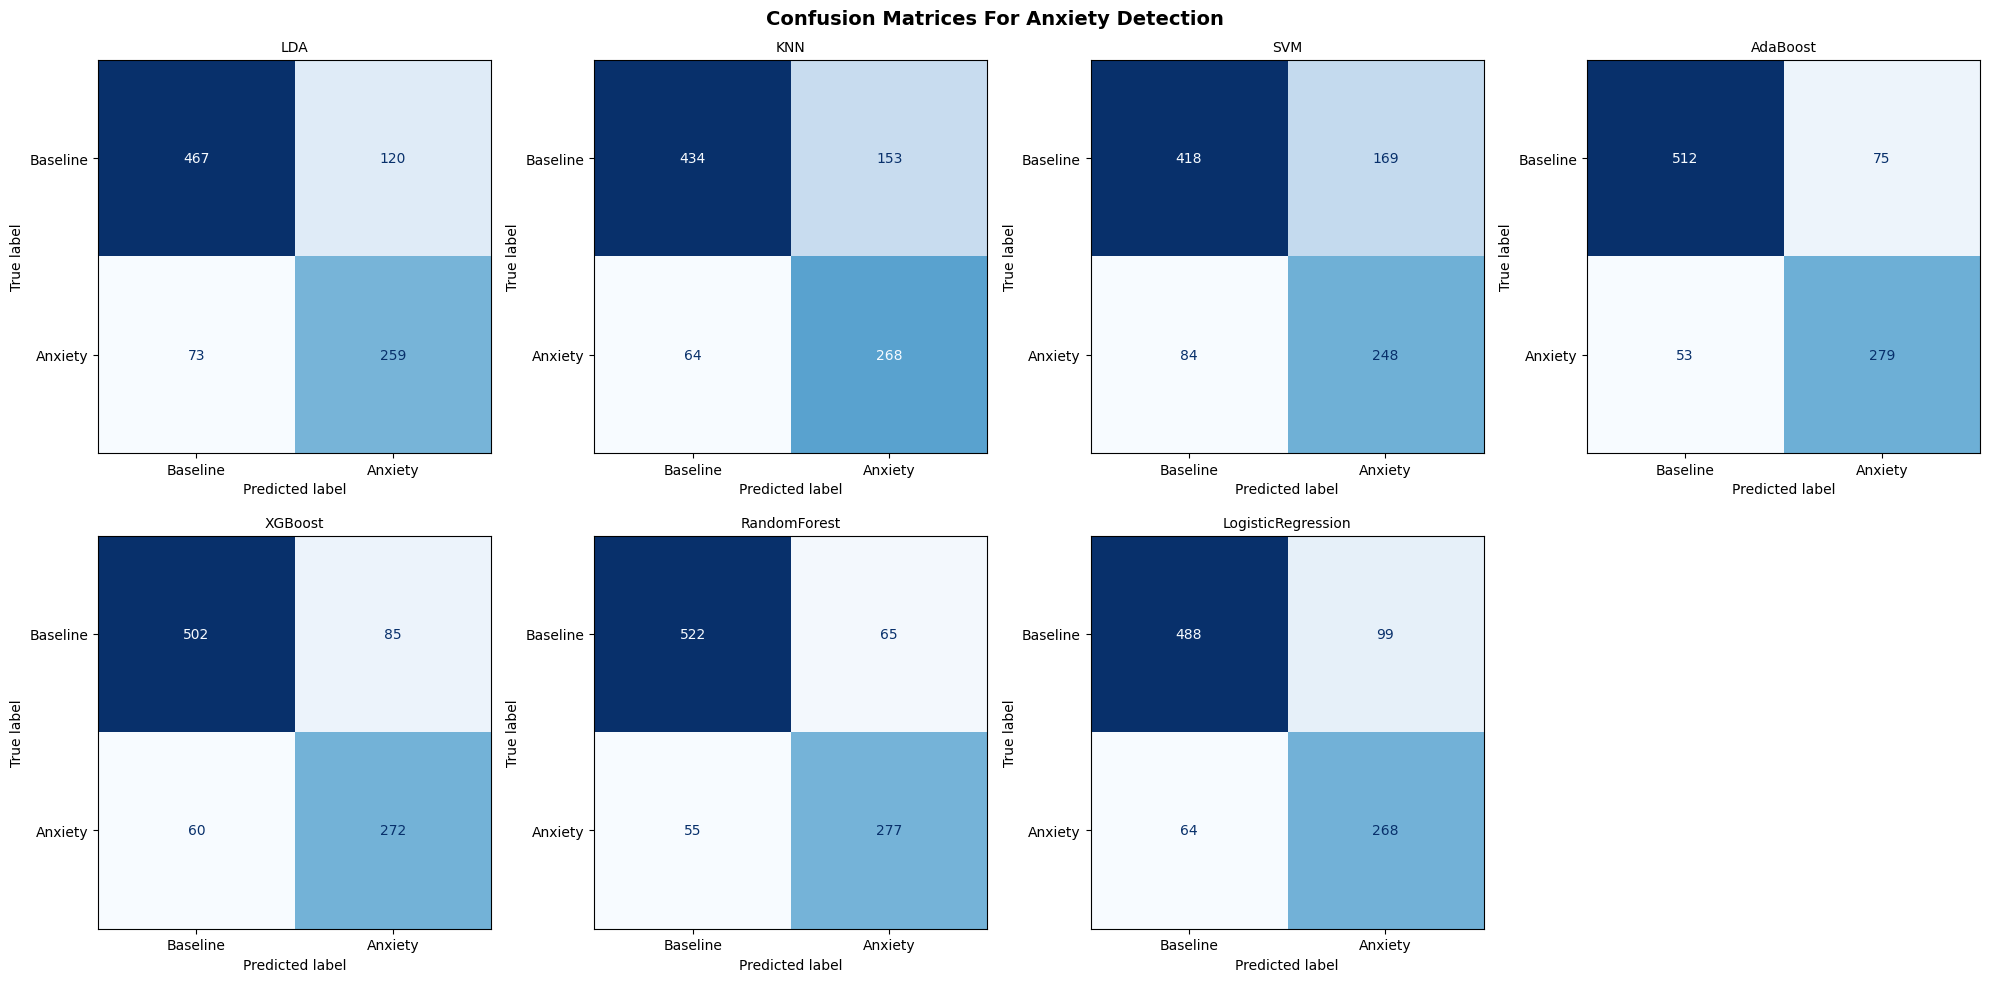

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, cm) in enumerate(all_cms.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    m = results_df.loc[name]
    axes[i].set_title(
        # f"{name}\nAcc={m['Accuracy']:.3f}  F1={m['F1-Score']:.3f}  MCC={m['MCC']:.3f}",
        f"{name}",
        fontsize=10
    )

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices For Anxiety Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_loso.png", dpi=150, bbox_inches="tight")
plt.show()


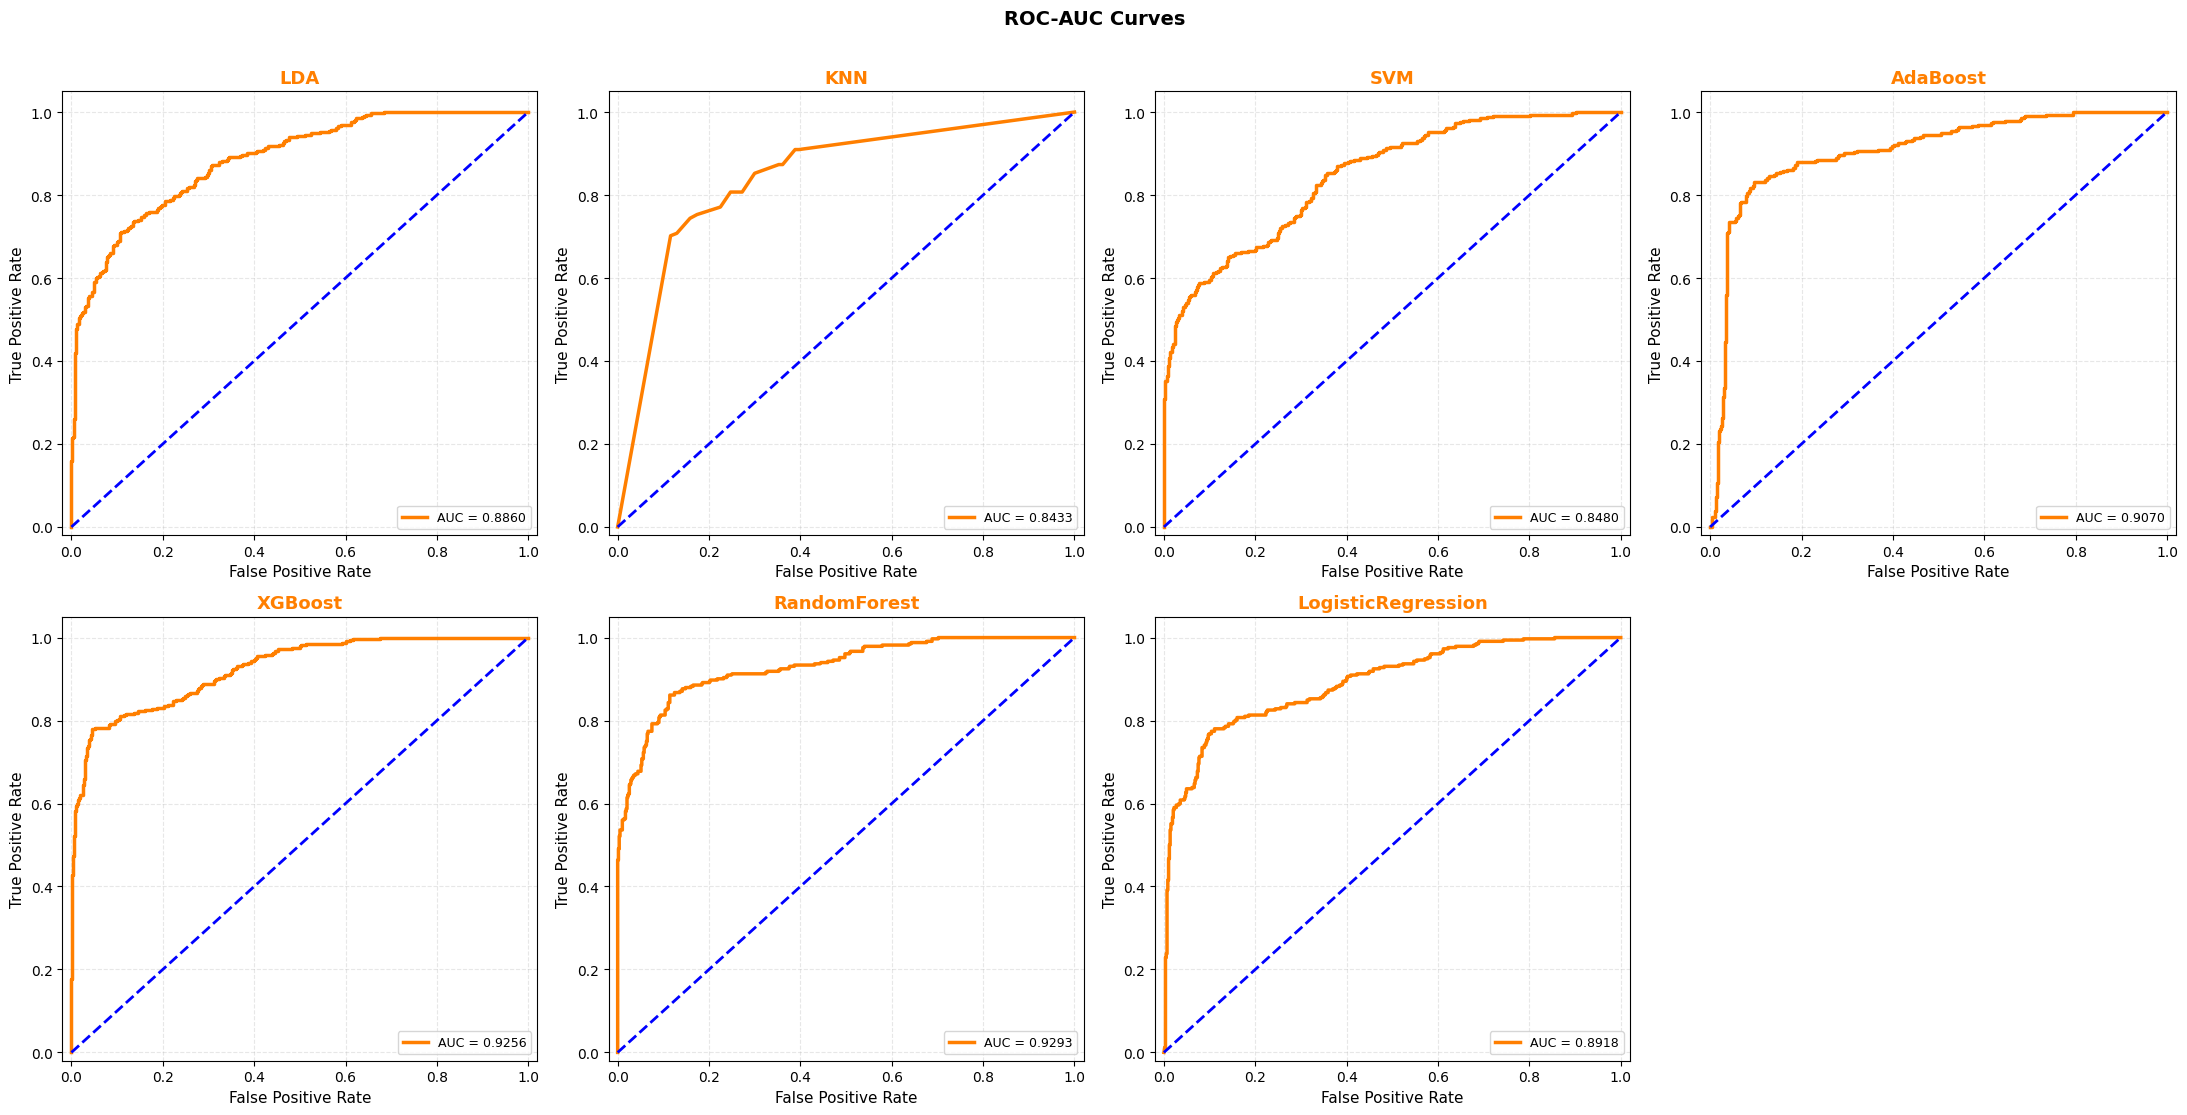

Saved: roc_auc_individual_models.png


In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc
import matplotlib.pyplot as plt
import numpy as np

COLORS = {
    "LDA":                "#ff7f00",
    "KNN":                "#ff7f00",
    "SVM":                "#ff7f00",
    "AdaBoost":           "#ff7f00",
    "XGBoost":            "#ff7f00",
    "RandomForest":       "#ff7f00",
    "LogisticRegression": "#ff7f00",
}

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for i, (name, store) in enumerate(fold_store.items()):

    yt  = np.array(store["y_true"])
    yb  = np.array(store["y_proba"])

    fpr, tpr, thresholds = roc_curve(yt, yb)
    roc_auc              = sk_auc(fpr, tpr)

    ax = axes[i]

    # ── Main ROC curve ───────────────────────────────────────
    ax.plot(fpr, tpr,
            color=COLORS[name], lw=2.5,
            label=f"AUC = {roc_auc:.4f}")

    # ── Random baseline diagonal ────────────────────────────
    ax.plot([0, 1], [0, 1],
            color="blue", lw=2, linestyle = "--")

    # ── Formatting ───────────────────────────────────────────
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate",  fontsize=11)
    ax.set_title(name, fontsize=13, fontweight="bold",
                 color=COLORS[name])
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3, linestyle="--")

# ── Hide the extra (8th) subplot ────────────────────────────
axes[-1].set_visible(False)

plt.suptitle(
    "ROC-AUC Curves",
    fontsize=14, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("roc_auc_individual_models.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: roc_auc_individual_models.png")

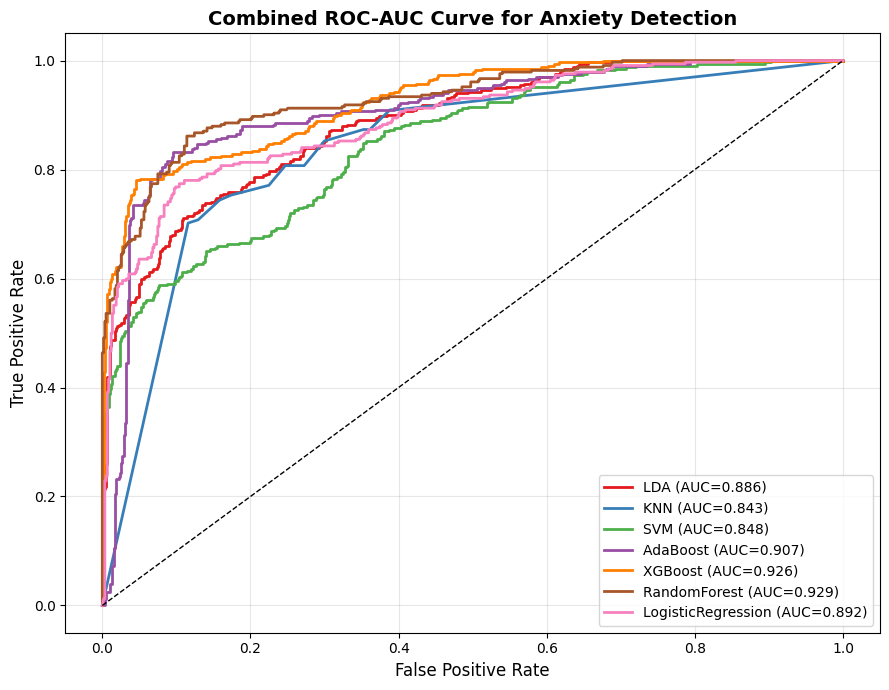

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc

fig, ax = plt.subplots(figsize=(9, 7))
COLORS  = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf"]

for (name, store), color in zip(fold_store.items(), COLORS):
    yt  = np.array(store["y_true"])
    yb  = np.array(store["y_proba"])
    fpr, tpr, _ = roc_curve(yt, yb)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC={sk_auc(fpr,tpr):.3f})")

ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("Combined ROC-AUC Curve for Anxiety Detection", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves_loso.png", dpi=150, bbox_inches="tight")
plt.show()

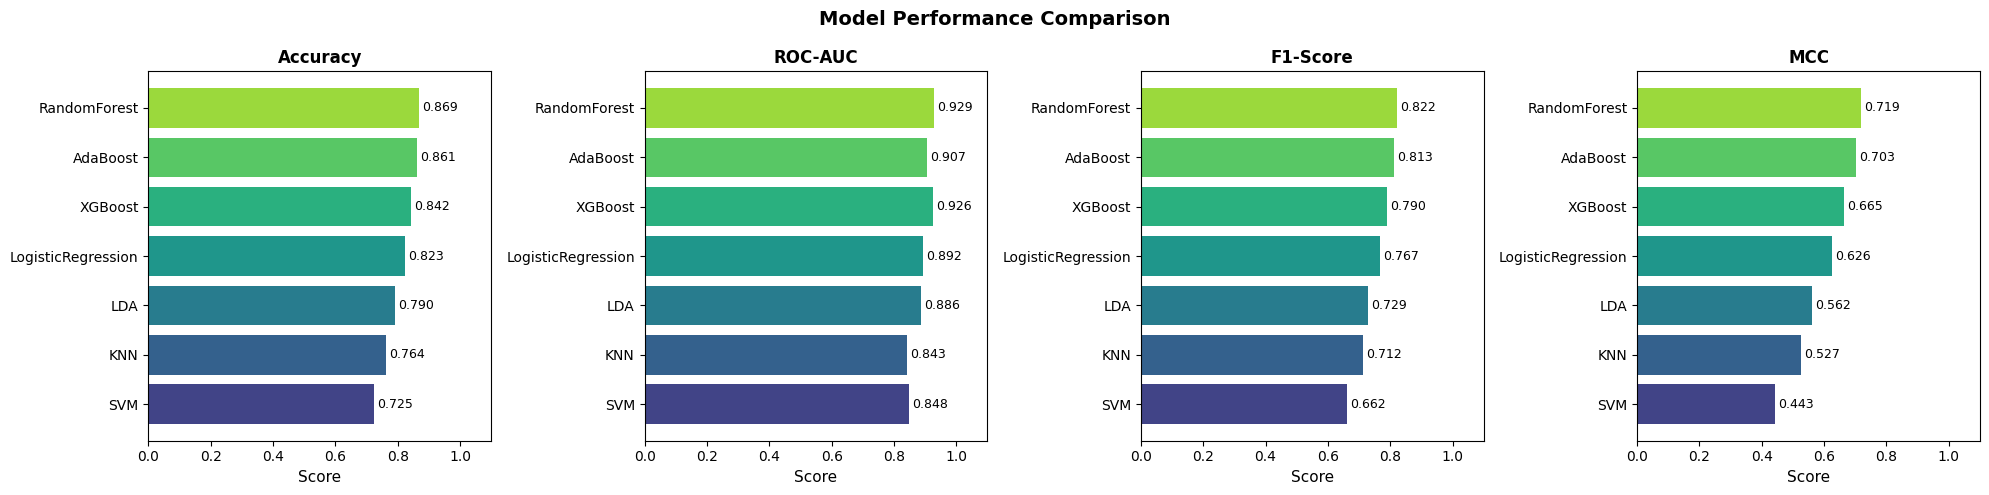

In [ ]:
metrics_to_plot = ["Accuracy", "ROC-AUC", "F1-Score", "MCC"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals  = results_df[metric].values
    names = results_df.index.tolist()
    bars  = ax.barh(names, vals,
                    color=plt.cm.viridis(np.linspace(0.2, 0.85, len(names))))
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("Score", fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

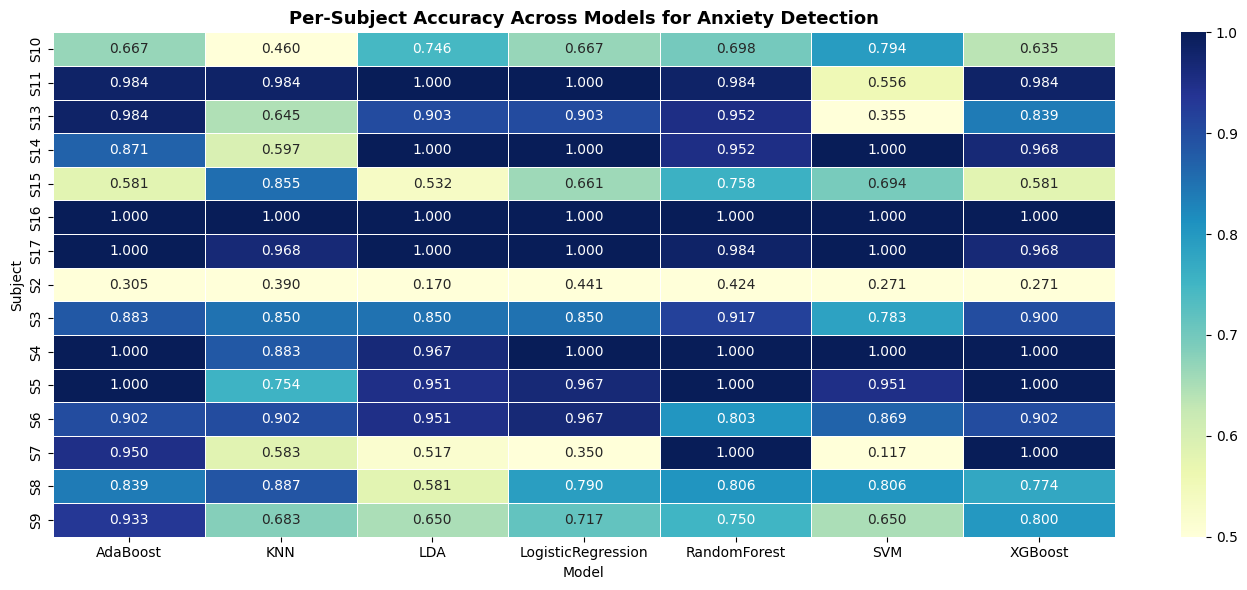

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(per_subj_df, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title("Per-Subject Accuracy Across Models for Anxiety Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("per_subject_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)
for name, store in fold_store.items():
    yt = np.array(store["y_true"])
    yp = np.array(store["y_pred"])
    print(f"\n--- {name} ---")
    print(classification_report(yt, yp, target_names=CLASS_NAMES))



DETAILED CLASSIFICATION REPORTS

--- LDA ---
              precision    recall  f1-score   support

    Baseline       0.86      0.80      0.83       587
     Anxiety       0.68      0.78      0.73       332

    accuracy                           0.79       919
   macro avg       0.77      0.79      0.78       919
weighted avg       0.80      0.79      0.79       919


--- KNN ---
              precision    recall  f1-score   support

    Baseline       0.87      0.74      0.80       587
     Anxiety       0.64      0.81      0.71       332

    accuracy                           0.76       919
   macro avg       0.75      0.77      0.76       919
weighted avg       0.79      0.76      0.77       919


--- SVM ---
              precision    recall  f1-score   support

    Baseline       0.83      0.71      0.77       587
     Anxiety       0.59      0.75      0.66       332

    accuracy                           0.72       919
   macro avg       0.71      0.73      0.71       919
we

Training models for feature importance extraction...
  LDA trained.
  KNN trained.
  SVM trained.
  AdaBoost trained.
  XGBoost trained.
  RandomForest trained.
  LogisticRegression trained.


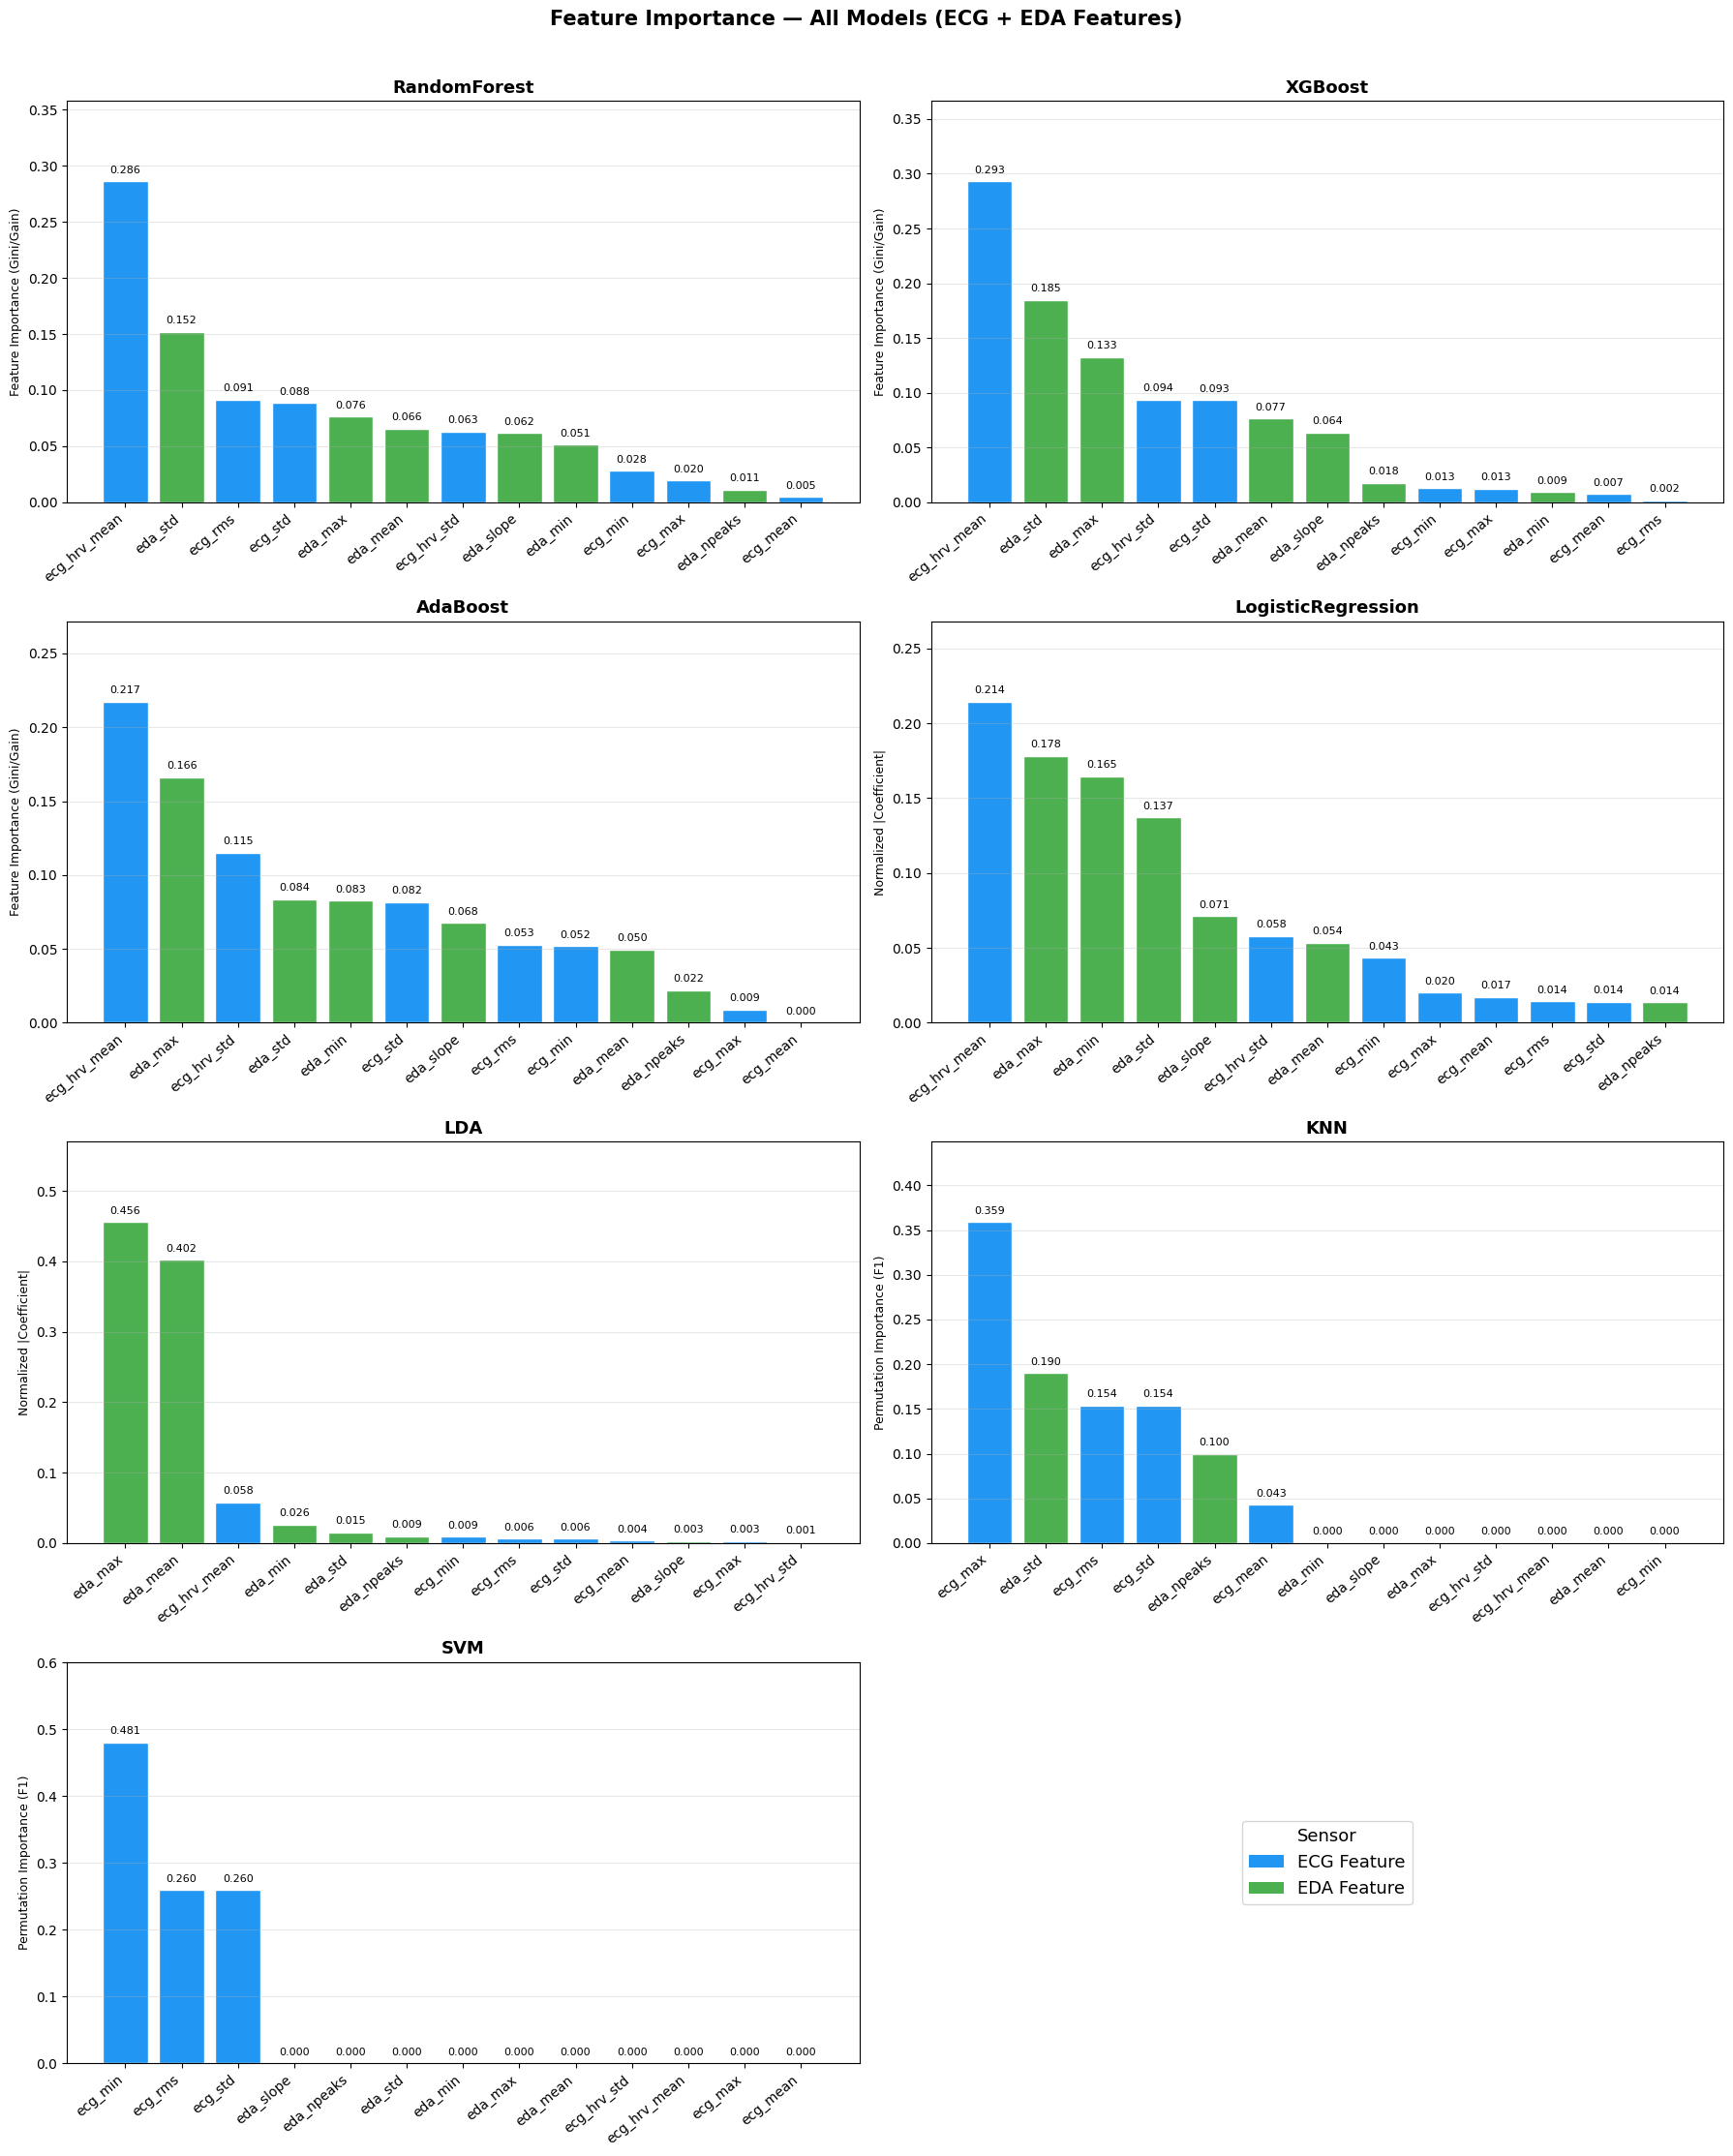

Saved: feature_importance_all_models.png


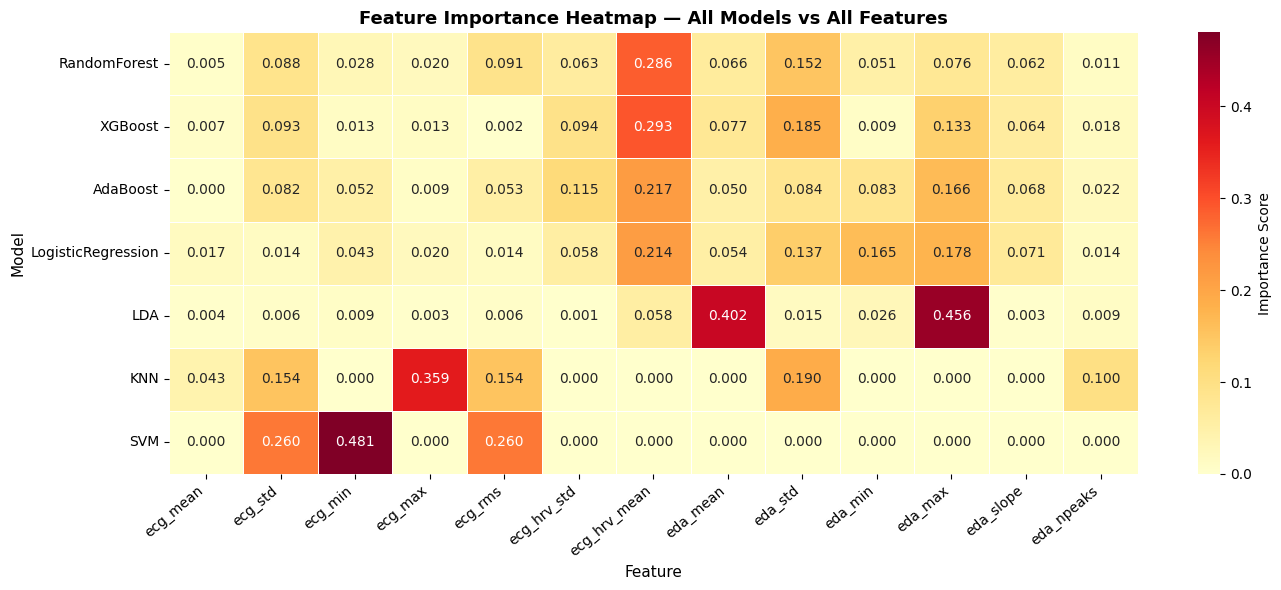

Saved: feature_importance_heatmap.png


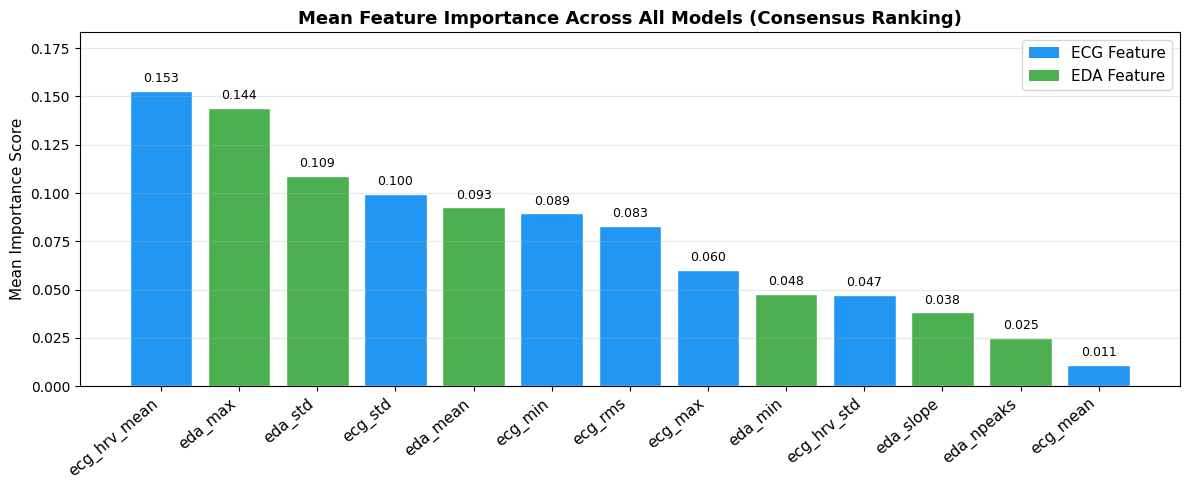

Saved: feature_importance_consensus.png

FEATURE IMPORTANCE RANKINGS (normalized scores)
              RandomForest  XGBoost  AdaBoost  LogisticRegression    LDA    KNN    SVM
ecg_mean            0.0050   0.0075    0.0000              0.0173 0.0037 0.0429 0.0000
ecg_std             0.0885   0.0932    0.0819              0.0141 0.0062 0.1539 0.2596
ecg_min             0.0282   0.0130    0.0519              0.0433 0.0091 0.0000 0.4807
ecg_max             0.0196   0.0125    0.0089              0.0201 0.0028 0.3590 0.0000
ecg_rms             0.0914   0.0018    0.0529              0.0143 0.0062 0.1539 0.2596
ecg_hrv_std         0.0628   0.0939    0.1152              0.0581 0.0015 0.0000 0.0000
ecg_hrv_mean        0.2861   0.2931    0.2174              0.2144 0.0577 0.0000 0.0000
eda_mean            0.0657   0.0765    0.0495              0.0536 0.4024 0.0000 0.0000
eda_std             0.1521   0.1848    0.0837              0.1372 0.0153 0.1902 0.0000
eda_min             0.0513   0.0093    0.

In [ ]:
# ============================================================
# FEATURE IMPORTANCE — All 7 Models
# Methods:
#   Tree-based  (RF, XGBoost, AdaBoost) → built-in importance
#   Linear      (LDA, LogReg)           → absolute coefficients
#   SVM                                 → permutation importance
#   KNN                                 → permutation importance
# ============================================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

FEATURE_NAMES = [
    "ecg_mean", "ecg_std", "ecg_min", "ecg_max", "ecg_rms",
    "ecg_hrv_std", "ecg_hrv_mean",
    "eda_mean", "eda_std", "eda_min", "eda_max", "eda_slope", "eda_npeaks"
]

# ── Use the final trained models from the last LOSO fold ─────
# Re-train once on all subjects except one (S2) for importance extraction
# This gives a stable, fully-trained model to inspect

IMPORTANCE_TEST_SUBJECT = 2
train_sids = [s for s in SUBJECTS if s != IMPORTANCE_TEST_SUBJECT]

X_imp_train_list, y_imp_train_list = [], []
for sid in train_sids:
    try:
        ecg, eda, labels = load_subject(sid)
        X_s, y_s = extract_windows(ecg, eda, labels)
        X_imp_train_list.append(X_s)
        y_imp_train_list.append(y_s)
    except FileNotFoundError:
        pass

X_imp_train = np.vstack(X_imp_train_list)
y_imp_train = np.hstack(y_imp_train_list)

# Load test subject for permutation importance
ecg_t, eda_t, lbl_t  = load_subject(IMPORTANCE_TEST_SUBJECT)
X_imp_test, y_imp_test = extract_windows(ecg_t, eda_t, lbl_t)

# SMOTE on training data
smote = SMOTE(random_state=42)
X_imp_res, y_imp_res = smote.fit_resample(X_imp_train, y_imp_train)

# Train all models once
print("Training models for feature importance extraction...")
importance_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (clf, param_grid) in get_models().items():
    pipe = Pipeline([
        ("scaler",     StandardScaler()),
        ("classifier", clf)
    ])
    if param_grid:
        gs = GridSearchCV(pipe, param_grid, cv=skf,
                          scoring="f1", n_jobs=-1, refit=True)
        gs.fit(X_imp_res, y_imp_res)
        importance_models[name] = gs.best_estimator_
    else:
        pipe.fit(X_imp_res, y_imp_res)
        importance_models[name] = pipe
    print(f"  {name} trained.")

# ── Extract importance per model ──────────────────────────────

def get_importance(name, model, X_test, y_test):
    clf = model.named_steps["classifier"]

    # Tree-based: built-in feature_importances_
    if name in ["RandomForest", "XGBoost", "AdaBoost"]:
        return clf.feature_importances_, "Feature Importance (Gini/Gain)"

    # Linear models: absolute coefficients
    if name == "LogisticRegression":
        coef = np.abs(clf.coef_[0])
        return coef / coef.sum(), "Normalized |Coefficient|"

    if name == "LDA":
        coef = np.abs(clf.coef_[0])
        return coef / coef.sum(), "Normalized |Coefficient|"

    # KNN and SVM: permutation importance on test subject
    if name in ["KNN", "SVM"]:
        # Scale test data using the pipeline's scaler
        scaler   = model.named_steps["scaler"]
        X_scaled = scaler.transform(X_test)
        perm     = permutation_importance(
            clf, X_scaled, y_test,
            n_repeats=30, random_state=42,
            scoring="f1", n_jobs=-1
        )
        imp = np.maximum(perm.importances_mean, 0)   # clip negatives to 0
        return imp / imp.sum() if imp.sum() > 0 else imp, "Permutation Importance (F1)"

# ── Plot: Individual bar chart per model ─────────────────────

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

model_order = ["RandomForest", "XGBoost", "AdaBoost",
               "LogisticRegression", "LDA", "KNN", "SVM"]

all_importances = {}

for i, name in enumerate(model_order):
    model  = importance_models[name]
    imp, ylabel = get_importance(name, model, X_imp_test, y_imp_test)
    all_importances[name] = imp

    idx    = np.argsort(imp)[::-1]
    sorted_imp   = imp[idx]
    sorted_names = [FEATURE_NAMES[j] for j in idx]

    # Color: ECG features blue, EDA features green
    colors = ["#2196F3" if "ecg" in fn else "#4CAF50" for fn in sorted_names]

    bars = axes[i].bar(range(len(imp)), sorted_imp, color=colors, edgecolor="white")
    axes[i].set_xticks(range(len(imp)))
    axes[i].set_xticklabels(sorted_names, rotation=40, ha="right", fontsize=10)
    axes[i].set_title(f"{name}", fontsize=13, fontweight="bold")
    axes[i].set_ylabel(ylabel, fontsize=9)
    axes[i].set_ylim(0, sorted_imp[0] * 1.25)
    axes[i].grid(axis="y", alpha=0.3)

    # Value labels on bars
    for bar, v in zip(bars, sorted_imp):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + sorted_imp[0] * 0.02,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)

# Legend for ECG vs EDA
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="ECG Feature"),
    Patch(facecolor="#4CAF50", label="EDA Feature")
]
axes[-1].axis("off")
axes[-1].legend(handles=legend_elements, fontsize=13,
                loc="center", title="Sensor", title_fontsize=13)

plt.suptitle("Feature Importance — All Models (ECG + EDA Features)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_importance_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_all_models.png")

# ── Plot: Heatmap of importances across all models ───────────

imp_matrix = np.array([all_importances[n] for n in model_order])
imp_df     = pd.DataFrame(imp_matrix, index=model_order, columns=FEATURE_NAMES)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    imp_df, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Importance Score"}
)
ax.set_title("Feature Importance Heatmap — All Models vs All Features",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Model",   fontsize=11)
plt.xticks(rotation=40, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig("feature_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_heatmap.png")

# ── Plot: Mean importance across all models (consensus) ──────

mean_imp = imp_df.mean(axis=0).sort_values(ascending=False)
colors   = ["#2196F3" if "ecg" in f else "#4CAF50" for f in mean_imp.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(mean_imp)), mean_imp.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(mean_imp)))
ax.set_xticklabels(mean_imp.index, rotation=40, ha="right", fontsize=11)
ax.set_title("Mean Feature Importance Across All Models (Consensus Ranking)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Importance Score", fontsize=11)
ax.set_ylim(0, mean_imp.values[0] * 1.2)
ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="ECG Feature"),
    Patch(facecolor="#4CAF50", label="EDA Feature")
]
ax.legend(handles=legend_elements, fontsize=11)

for bar, v in zip(bars, mean_imp.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + mean_imp.values[0] * 0.02,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance_consensus.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_consensus.png")

# ── Print ranked importance table ────────────────────────────

print("\n" + "="*65)
print("FEATURE IMPORTANCE RANKINGS (normalized scores)")
print("="*65)
print(imp_df.T.to_string(float_format="{:.4f}".format))

print("\n\nCONSENSUS RANKING (mean across all models):")
print("-"*40)
for rank, (feat, val) in enumerate(mean_imp.items(), 1):
    sensor = "ECG" if "ecg" in feat else "EDA"
    print(f"  {rank:2d}. {feat:<15s} [{sensor}]  {val:.4f}")

In [ ]:
import pickle
from google.colab import files

# ── Step 1: Identify the best model by Accuracy ──────────────
best_model_name = results_df["Accuracy"].idxmax()
print(f"Best model: {best_model_name} (Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f})")

# ── Step 2: Retrain the best model on ALL data ────────────────
# (importance_models already trained on all-but-one subject;
#  for a truly final model, retrain on the full dataset)
best_clf, best_params = get_models()[best_model_name]

smote = SMOTE(random_state=42)
X_full_res, y_full_res = smote.fit_resample(X_all, y_all)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", best_clf)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_params:
    gs = GridSearchCV(pipe, best_params, cv=skf, scoring="f1", n_jobs=-1, refit=True)
    gs.fit(X_full_res, y_full_res)
    final_model = gs.best_estimator_
else:
    pipe.fit(X_full_res, y_full_res)
    final_model = pipe

# ── Step 3: Save as .pkl ──────────────────────────────────────
pkl_filename = f"best_model_{best_model_name}.pkl"
with open(pkl_filename, "wb") as f:
    pickle.dump(final_model, f)

print(f"Saved: {pkl_filename}")

# ── Step 4: Download it ───────────────────────────────────────
files.download(pkl_filename)

Best model: RandomForest (Accuracy: 0.8694)
Saved: best_model_RandomForest.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

# Get the name of the best performing model from the results_df
best_model_name = results_df.index[-1]

# Retrieve the trained pipeline for the best model from the importance_models dictionary
# These models were trained on most of the data for feature importance calculation,
# providing a good representative model to save.
best_pipeline = importance_models[best_model_name]

# Define a filename for the saved model
model_filename = f"{best_model_name.lower().replace(' ', '_')}_pipeline.pkl"

# Save the pipeline using pickle
with open(model_filename, 'wb') as file:
    pickle.dump(best_pipeline, file)

print(f"The best model ({best_model_name}) pipeline has been saved as {model_filename}")

# You can also move this file to Google Drive if needed:
# from google.colab import drive
# import shutil
# drive_path = '/content/drive/MyDrive/SavedModels/'
# os.makedirs(drive_path, exist_ok=True)
# shutil.move(model_filename, drive_path + model_filename)
# print(f"Model moved to Google Drive: {drive_path + model_filename}")

The best model (RandomForest) pipeline has been saved as randomforest_pipeline.pkl
